In [5]:
import pandas as pd
import zipfile
with zipfile.ZipFile('archive.zip', 'r') as z:
    print(z.namelist())

['StudentsPerformance.csv']


In [6]:
df = pd.read_csv('archive.zip')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average_score'] = df['total_score'] / 3
df['status'] = df.apply(lambda row: 'Pass' if row['math score'] >= 40 and row['reading score'] >= 40 and row['writing score'] >= 40 else 'Fail', axis=1)
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score,status
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Pass
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Pass
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Pass
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Pass


Matplotlib is building the font cache; this may take a moment.


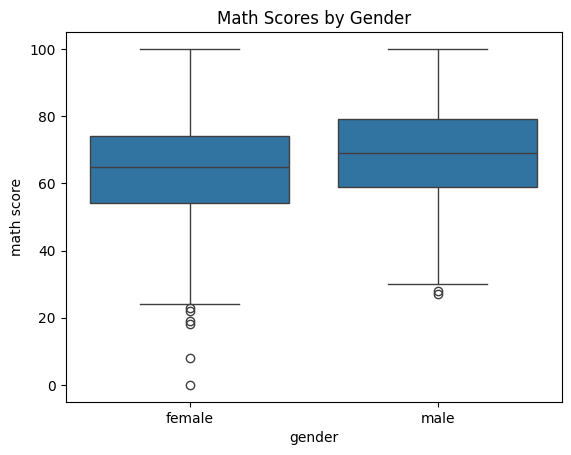

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x='gender', y='math score', data=df)
plt.title('Math Scores by Gender')
plt.show()


In [10]:
%pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 443.2 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/8.3 MB 443.2 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/8.3 MB 443.2 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/8.3 MB 384.9 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.3 MB 384.9 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.3 MB 384.9 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/8.3 MB 384.9 kB/s eta 0:00:20
   --- ---------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


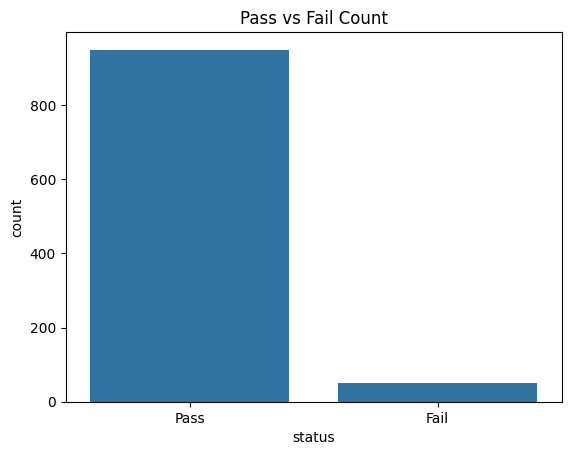

In [12]:
sns.countplot(x='status', data=df)
plt.title('Pass vs Fail Count')
plt.show()


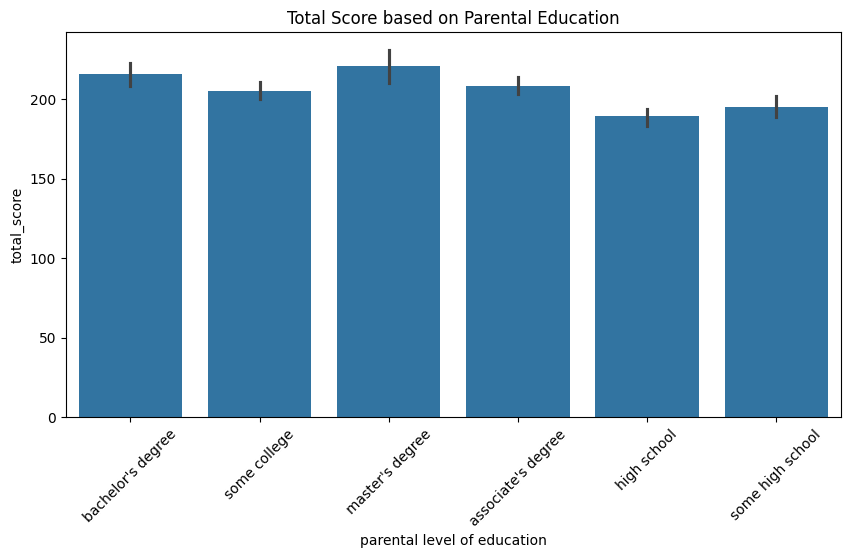

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(x='parental level of education', y='total_score', data=df)
plt.xticks(rotation=45)
plt.title('Total Score based on Parental Education')
plt.show()


In [14]:
df.to_csv('Cleaned_Students_Performance.csv', index=False)
